In [7]:
import tempfile
import os

# 📍【关键修复 1】：重定向 Catalyst 的临时文件，彻底解决超算节点硬盘爆满的问题！
custom_tmp_path = os.path.join(os.getcwd(), "catalyst_tmp_cache")
os.makedirs(custom_tmp_path, exist_ok=True)
os.environ['TMPDIR'] = custom_tmp_path
tempfile.tempdir = custom_tmp_path
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import time
import math
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from scipy.sparse import coo_matrix

import jax
# 开启双精度
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import optax
import pennylane as qml
import catalyst
qml.about()


Name: pennylane
Version: 0.43.1
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
Author-email: 
License-Expression: Apache-2.0
Location: /home/lzs/.conda/envs/lzsgpu/lib/python3.12/site-packages
Requires: appdirs, autograd, autoray, cachetools, diastatic-malt, networkx, numpy, packaging, pennylane-lightning, requests, rustworkx, scipy, tomlkit, typing_extensions
Required-by: pennylane_catalyst, pennylane_lightning, pennylane_lightning_gpu

Platform info:           Linux-6.11.0-26-generic-x86_64-with-glibc2.39
Python version:          3.12.12
Numpy version:           2.3.4
Scipy version:           1.16.2
JAX version:             0.6.2
Installed devices:
- default.clifford (pennylane-0.43.1)
- default.gaussian (pennylane-0.43.1)
- default.mixed (pennylane-0.43.1)
- default.qubit (pennylane-0.43.1)
- default.qutrit (pennylane-0.43.1)


In [8]:
# =================== 0. 环境与硬件检查 ===================
print('✅ JAX version:', jax.__version__)
print('✅ Devices:', jax.devices())
if any(d.platform == 'gpu' for d in jax.devices()):
    print('🎉 GPU is working!')
else:
    print('⚠️ No GPU detected')


✅ JAX version: 0.6.2
✅ Devices: [CudaDevice(id=0)]
🎉 GPU is working!


In [9]:
# =================== 1. 数据准备 (直接使用 A100 的大显存优势) ===================
matrix_candidates = ["L=5 N=4.npz", os.path.join("lunwen", "L=5 N=4.npz")]
matrix_file = next((p for p in matrix_candidates if os.path.exists(p)), None)
if matrix_file is None:
    raise FileNotFoundError(f"Cannot find matrix file. Tried: {matrix_candidates}")
H_3 = sp.load_npz(matrix_file)
print(f"使用矩阵文件: {matrix_file}")

min_eigvals, _ = eigsh(H_3, k=1, which='SA')
exact_min_energy = float(min_eigvals[0])
print(f"最小特征值 (理论极限): {exact_min_energy:.8f}")

d = H_3.shape[0]
n_qubits = int(np.ceil(np.log2(d)))
l = 2 ** n_qubits
depth = math.ceil(2**n_qubits / n_qubits) + n_qubits
print(f'电路深度: {depth}, 参数总量: {depth * n_qubits}')

# 补全到 2^Nq 并 Gray 编码 (逻辑和之前一样)
H_3_coo = H_3.tocoo()
rows, cols, data = H_3_coo.row.astype(np.int64), H_3_coo.col.astype(np.int64), H_3_coo.data
if l > d:
    rows = np.concatenate([rows, np.arange(d, l, dtype=np.int64)])
    cols = np.concatenate([cols, np.arange(d, l, dtype=np.int64)])
    data = np.concatenate([data, np.full(l - d, 1000.0, dtype=data.dtype)])

def gray_code(n):
    if n == 1: return ["0", "1"]
    lower = gray_code(n - 1)
    return ["0" + x for x in lower] + ["1" + x for x in reversed(lower)]

gray_basis = gray_code(n_qubits)
gray2natural = np.array([int(g, 2) for g in gray_basis], dtype=np.int64)
new_rows, new_cols = gray2natural[rows], gray2natural[cols]
H_gray_csr = coo_matrix((data, (new_rows, new_cols)), shape=(l, l)).tocsr()

# 📍【关键修复 2】：A100 显存管够！直接将 4GB 的矩阵转化为 JAX 密集数组传入 GPU，速度拉满！
H_dense = H_gray_csr.toarray()
H_jax = jnp.array(H_dense, dtype=jnp.complex128)
del H_3, H_3_coo, H_gray_csr, H_dense


使用矩阵文件: L=5 N=4.npz
最小特征值 (理论极限): -35.68407846
电路深度: 354, 参数总量: 4248


In [10]:
# =================== 2. 量子电路与 Catalyst 编译 ===================
hf = np.zeros(n_qubits, dtype=int)
dev = qml.device("lightning.gpu", wires=n_qubits)

# 📍【关键修改 1】：在 qnode 外部提前定义好一个纯 Python 列表！
all_wires = list(range(n_qubits))

# 📍【关键 2】：恢复 H_mat 参数
@qml.qnode(dev)
def cost_circuit(params_2d, H_mat):
    qml.BasisState(hf, wires=all_wires)

    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    for d_idx in range(depth):
        for i in range(n_qubits):
            qml.RY(params_2d[d_idx, i], wires=i)

        for i in range(0, n_qubits - 1, 2):
            qml.CNOT(wires=[i, i + 1])

        qml.CNOT(wires=[n_qubits - 1, 0])

        for i in range(1, n_qubits - 1, 2):
            qml.CNOT(wires=[i, i + 1])

    return qml.expval(qml.Hermitian(H_mat, wires=all_wires))

# =================== 五阶段优化器配置（精度优先） ===================
seed = 42
key = jax.random.PRNGKey(seed)
# 小随机初始化，避免全零初始化早期陷入对称路径
init_params = 0.005 * jax.random.normal(key, shape=(depth, n_qubits), dtype=jnp.float64)

# Stage-1: 快速下降
schedule_stage1 = optax.exponential_decay(init_value=8e-3, transition_steps=250, decay_rate=0.72)
opt_stage1 = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=schedule_stage1, eps=1e-8),
)

# Stage-2: 主力收敛
schedule_stage2 = optax.exponential_decay(init_value=2e-3, transition_steps=500, decay_rate=0.85)
opt_stage2 = optax.chain(
    optax.clip_by_global_norm(0.20),
    optax.adam(learning_rate=schedule_stage2, eps=1e-8),
)

# Stage-3: 细化收敛
schedule_stage3 = optax.exponential_decay(init_value=8e-5, transition_steps=700, decay_rate=0.92)
opt_stage3 = optax.chain(
    optax.clip_by_global_norm(0.08),
    optax.adam(learning_rate=schedule_stage3, eps=1e-8),
)

# Stage-4: 超精修（进一步降低步长）
schedule_stage4 = optax.exponential_decay(init_value=3e-5, transition_steps=900, decay_rate=0.96)
opt_stage4 = optax.chain(
    optax.clip_by_global_norm(0.05),
    optax.adam(learning_rate=schedule_stage4, eps=1e-8),
)

# Stage-5: 极限精修（最后挤精度）
schedule_stage5 = optax.exponential_decay(init_value=8e-6, transition_steps=1200, decay_rate=0.98)
opt_stage5 = optax.chain(
    optax.clip_by_global_norm(0.03),
    optax.adam(learning_rate=schedule_stage5, eps=1e-8),
)

opt_state_stage1 = opt_stage1.init(init_params)

@qml.qjit(autograph=True)
def update_step_stage1(current_params, current_opt_state, H_matrix):
    def cost_fn(p):
        return cost_circuit(p, H_matrix)

    energy, grads = catalyst.value_and_grad(cost_fn)(current_params)
    updates, next_opt_state = opt_stage1.update(grads, current_opt_state, current_params)
    next_params = optax.apply_updates(current_params, updates)
    return next_params, next_opt_state, energy

@qml.qjit(autograph=True)
def update_step_stage2(current_params, current_opt_state, H_matrix):
    def cost_fn(p):
        return cost_circuit(p, H_matrix)

    energy, grads = catalyst.value_and_grad(cost_fn)(current_params)
    updates, next_opt_state = opt_stage2.update(grads, current_opt_state, current_params)
    next_params = optax.apply_updates(current_params, updates)
    return next_params, next_opt_state, energy

@qml.qjit(autograph=True)
def update_step_stage3(current_params, current_opt_state, H_matrix):
    def cost_fn(p):
        return cost_circuit(p, H_matrix)

    energy, grads = catalyst.value_and_grad(cost_fn)(current_params)
    updates, next_opt_state = opt_stage3.update(grads, current_opt_state, current_params)
    next_params = optax.apply_updates(current_params, updates)
    return next_params, next_opt_state, energy

@qml.qjit(autograph=True)
def update_step_stage4(current_params, current_opt_state, H_matrix):
    def cost_fn(p):
        return cost_circuit(p, H_matrix)

    energy, grads = catalyst.value_and_grad(cost_fn)(current_params)
    updates, next_opt_state = opt_stage4.update(grads, current_opt_state, current_params)
    next_params = optax.apply_updates(current_params, updates)
    return next_params, next_opt_state, energy

@qml.qjit(autograph=True)
def update_step_stage5(current_params, current_opt_state, H_matrix):
    def cost_fn(p):
        return cost_circuit(p, H_matrix)

    energy, grads = catalyst.value_and_grad(cost_fn)(current_params)
    updates, next_opt_state = opt_stage5.update(grads, current_opt_state, current_params)
    next_params = optax.apply_updates(current_params, updates)
    return next_params, next_opt_state, energy


In [ ]:
# =================== 3. 精度优先训练循环 ===================
params = init_params
target_energy = exact_min_energy
tolerance = 1e-7
steps = 5000
switch_step_1 = 400   # Stage-1 -> Stage-2
switch_step_2 = 2200   # Stage-2 -> Stage-3
switch_step_3 = 3400   # Stage-3 -> Stage-4
switch_step_4 = 4300   # Stage-4 -> Stage-5

# 若长时间没有刷新 best，就提前切阶段
stagnation_patience_stage1 = 120
stagnation_patience_stage2 = 140
stagnation_patience_stage3 = 180
stagnation_patience_stage4 = 220
improve_tol = 1e-10

best_energy = float("inf")
best_step = -1
best_params = params

# 保存每一步的能量
energy_history = []

opt_state = opt_state_stage1
current_stage = 1
no_improve_steps = 0

# 分阶段计步（用于打印当前学习率）
stage_step_1 = 0
stage_step_2 = 0
stage_step_3 = 0
stage_step_4 = 0
stage_step_5 = 0

# 梯度裁剪阈值（用于日志显示）
clip_stage_1 = 1.00
clip_stage_2 = 0.20
clip_stage_3 = 0.08
clip_stage_4 = 0.05
clip_stage_5 = 0.03

print("")
print("🚀 开始 Catalyst 五阶段训练（精度优先）...")
print(
    "配置: "
    f"S1(lr0=8e-3, clip={clip_stage_1}, decay=0.72/250) | "
    f"S2(lr0=2e-3, clip={clip_stage_2}, decay=0.85/500) | "
    f"S3(lr0=8e-5, clip={clip_stage_3}, decay=0.92/700) | "
    f"S4(lr0=3e-5, clip={clip_stage_4}, decay=0.96/900) | "
    f"S5(lr0=8e-6, clip={clip_stage_5}, decay=0.98/1200)"
)
start_time = time.time()

for i in range(steps):
    # 记录“本步实际使用”的阶段与超参数，避免切换时日志错位
    used_stage = current_stage

    if used_stage == 1:
        stage_local_step = stage_step_1
        lr_now = float(schedule_stage1(stage_local_step))
        clip_now = clip_stage_1
        params, opt_state, energy = update_step_stage1(params, opt_state, H_jax)
        stage_step_1 += 1
    elif used_stage == 2:
        stage_local_step = stage_step_2
        lr_now = float(schedule_stage2(stage_local_step))
        clip_now = clip_stage_2
        params, opt_state, energy = update_step_stage2(params, opt_state, H_jax)
        stage_step_2 += 1
    elif used_stage == 3:
        stage_local_step = stage_step_3
        lr_now = float(schedule_stage3(stage_local_step))
        clip_now = clip_stage_3
        params, opt_state, energy = update_step_stage3(params, opt_state, H_jax)
        stage_step_3 += 1
    elif used_stage == 4:
        stage_local_step = stage_step_4
        lr_now = float(schedule_stage4(stage_local_step))
        clip_now = clip_stage_4
        params, opt_state, energy = update_step_stage4(params, opt_state, H_jax)
        stage_step_4 += 1
    else:
        stage_local_step = stage_step_5
        lr_now = float(schedule_stage5(stage_local_step))
        clip_now = clip_stage_5
        params, opt_state, energy = update_step_stage5(params, opt_state, H_jax)
        stage_step_5 += 1

    current_energy = float(energy)
    energy_history.append(current_energy)

    if current_energy < (best_energy - improve_tol):
        best_energy = current_energy
        best_step = i
        best_params = params
        no_improve_steps = 0
    else:
        no_improve_steps += 1

    # 阶段切换策略：固定步数 or 停滞触发，并回滚到 best_params
    if current_stage == 1 and (i >= switch_step_1 or no_improve_steps >= stagnation_patience_stage1):
        reason = f"fixed_step={i}" if i >= switch_step_1 else f"plateau={no_improve_steps}"
        params = best_params
        current_stage = 2
        opt_state = opt_stage2.init(params)
        no_improve_steps = 0
        print(f"🔁 切换到 Stage-2, step={i}, reason={reason}, next_lr0=2e-3, next_clip={clip_stage_2}")

    elif current_stage == 2 and (i >= switch_step_2 or no_improve_steps >= stagnation_patience_stage2):
        reason = f"fixed_step={i}" if i >= switch_step_2 else f"plateau={no_improve_steps}"
        params = best_params
        current_stage = 3
        opt_state = opt_stage3.init(params)
        no_improve_steps = 0
        print(f"🔁 切换到 Stage-3, step={i}, reason={reason}, next_lr0=8e-5, next_clip={clip_stage_3}")

    elif current_stage == 3 and (i >= switch_step_3 or no_improve_steps >= stagnation_patience_stage3):
        reason = f"fixed_step={i}" if i >= switch_step_3 else f"plateau={no_improve_steps}"
        params = best_params
        current_stage = 4
        opt_state = opt_stage4.init(params)
        no_improve_steps = 0
        print(f"🔁 切换到 Stage-4, step={i}, reason={reason}, next_lr0=3e-5, next_clip={clip_stage_4}")

    elif current_stage == 4 and (i >= switch_step_4 or no_improve_steps >= stagnation_patience_stage4):
        reason = f"fixed_step={i}" if i >= switch_step_4 else f"plateau={no_improve_steps}"
        params = best_params
        current_stage = 5
        opt_state = opt_stage5.init(params)
        no_improve_steps = 0
        print(f"🔁 切换到 Stage-5, step={i}, reason={reason}, next_lr0=8e-6, next_clip={clip_stage_5}")

    if i % 50 == 0:
        print(
            f"Step = {i:4d}, Stage = {used_stage}, stage_step = {stage_local_step:4d}, "
            f"lr = {lr_now:.3e}, clip = {clip_now:.2f}, no_imp = {no_improve_steps:3d}, "
            f"Energy = {current_energy:.8f} Ha, Best = {best_energy:.8f} Ha, "
            f"Gap = {current_energy - exact_min_energy:.6f}"
        )

    if abs(current_energy - exact_min_energy) < tolerance:
        print("")
        print(f"🎉 成功收敛！ 在第 {i} 步达到能量: {current_energy:.8f} Ha")
        break

# 训练结束后回滚到历史最优参数
params = best_params

# 将所有能量转换为数组
energy_array = np.array(energy_history, dtype=np.float64)

print("-" * 30)
print(f"训练总耗时: {time.time() - start_time:.2f} 秒")
print(f"最后一步能量: {current_energy:.8f} Ha")
print(f"历史最优能量: {best_energy:.8f} Ha (step={best_step})")
print(f"最优能量差: {abs(best_energy - exact_min_energy):.8e} Ha")
print(f"energy_array 已生成，shape={energy_array.shape}")



🚀 开始 Catalyst 五阶段训练（精度优先）...
配置: S1(lr0=8e-3, clip=1.0, decay=0.72/250) | S2(lr0=2e-3, clip=0.2, decay=0.85/500) | S3(lr0=8e-5, clip=0.08, decay=0.92/700) | S4(lr0=3e-5, clip=0.05, decay=0.96/900) | S5(lr0=8e-6, clip=0.03, decay=0.98/1200)
Step =    0, Stage = 1, stage_step =    0, lr = 8.000e-03, clip = 1.00, no_imp =   0, Energy = 480.09743326 Ha, Best = 480.09743326 Ha, Gap = 515.781512


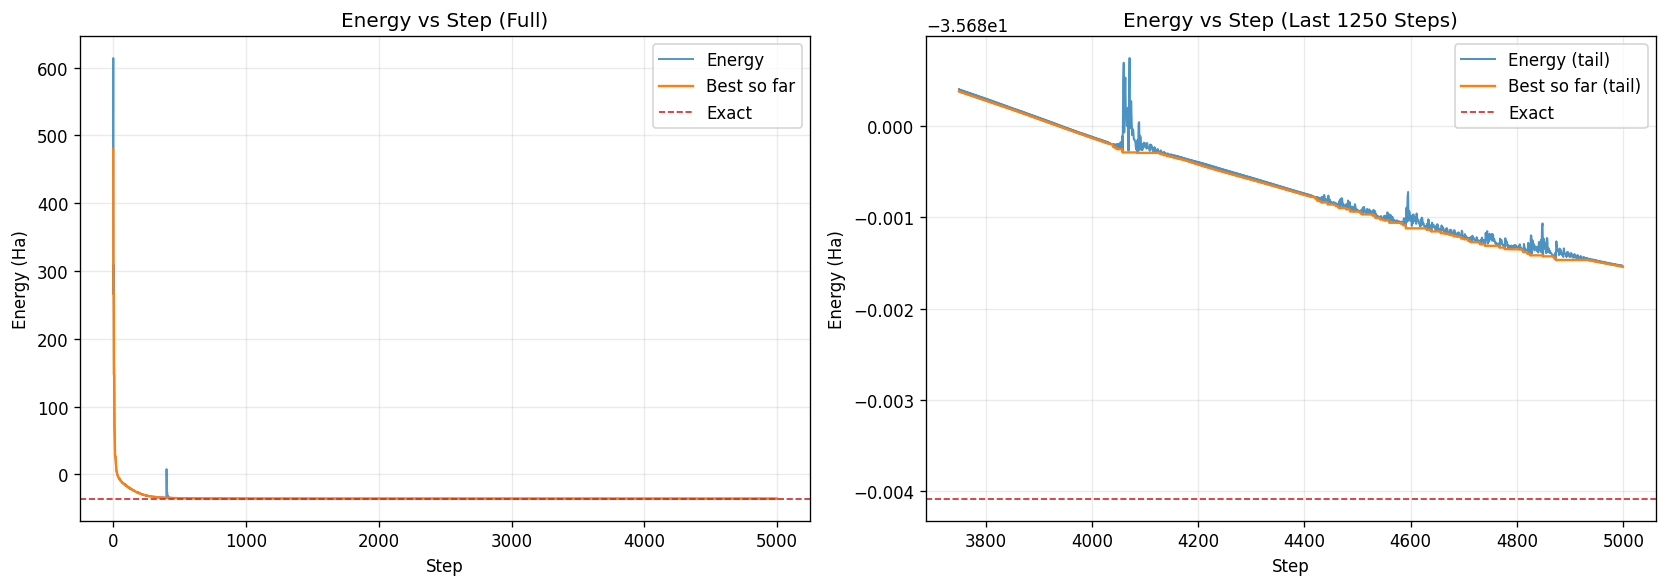

总步数: 5000
最终能量: -35.6815407846 Ha
历史最优: -35.6815407846 Ha
与精确值差距: 2.5376800414e-03 Ha


In [6]:
# =================== 4. 能量曲线可视化 ===================
import numpy as np
import matplotlib.pyplot as plt

if 'energy_array' not in globals():
    raise RuntimeError("未检测到 energy_array，请先运行训练单元。")

# 统一转为 NumPy 数组，避免类型差异
energy_plot = np.asarray(energy_array, dtype=np.float64)
steps_axis = np.arange(energy_plot.size)

# 历史最优包络线（单调不增）
best_so_far = np.minimum.accumulate(energy_plot)

# 取最后 25% 步数做局部放大，观察后期精修细节
tail_n = max(200, energy_plot.size // 4)
start_tail = max(0, energy_plot.size - tail_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# 左图：全程曲线
axes[0].plot(steps_axis, energy_plot, lw=1.2, alpha=0.75, label='Energy')
axes[0].plot(steps_axis, best_so_far, lw=1.4, label='Best so far')
if 'exact_min_energy' in globals():
    axes[0].axhline(float(exact_min_energy), ls='--', lw=1.0, color='tab:red', label='Exact')
axes[0].set_title('Energy vs Step (Full)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Energy (Ha)')
axes[0].grid(alpha=0.25)
axes[0].legend()

# 右图：后段放大
axes[1].plot(steps_axis[start_tail:], energy_plot[start_tail:], lw=1.2, alpha=0.8, label='Energy (tail)')
axes[1].plot(steps_axis[start_tail:], best_so_far[start_tail:], lw=1.4, label='Best so far (tail)')
if 'exact_min_energy' in globals():
    axes[1].axhline(float(exact_min_energy), ls='--', lw=1.0, color='tab:red', label='Exact')
axes[1].set_title(f'Energy vs Step (Last {energy_plot.size - start_tail} Steps)')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Energy (Ha)')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"总步数: {energy_plot.size}")
print(f"最终能量: {energy_plot[-1]:.10f} Ha")
print(f"历史最优: {best_so_far[-1]:.10f} Ha")
if 'exact_min_energy' in globals():
    print(f"与精确值差距: {best_so_far[-1] - float(exact_min_energy):.10e} Ha")
